In [55]:
import importlib
import utils
import visualisation_mod
import pandas as pd

# Force a fresh load of both modules
importlib.reload(utils)
importlib.reload(visualisation_mod)

from utils import MultimodalDatasetFactory
from visualisation_mod import UniverseVisualizer

print("✓ Modules synced and ready.")

✓ Modules synced and ready.


In [51]:
# Mount Google Drive (Standard Colab procedure for persistent storage)
# from google.colab import drive
# drive.mount('/content/drive')

# Define your root data directory
DATA_ROOT = "/content/drive/MyDrive/multimodal_universe"
factory = MultimodalDatasetFactory(base_path=DATA_ROOT)

In [52]:
# Index your available subsets (The 'Registration' phase)
factory.register_subset("image", "hubble_deep", {"resolution": "4k"})
factory.register_subset("time_series", "pulsar_v1", {"sampling_rate_hz": 1024, "dimensions": 1})

# Create the specific manifest for today's experiment
selection = {
    "image": ["hubble_deep"],
    "time_series": ["pulsar_v1"]
}
my_manifest = factory.combine_modalities(selection)

Successfully indexed hubble_deep [IMAGE]
Successfully indexed pulsar_v1 [TIME_SERIES]


In [53]:
# Pass the manifest generated by 'utils' into 'visualisation_mod'
viz = UniverseVisualizer(my_manifest)

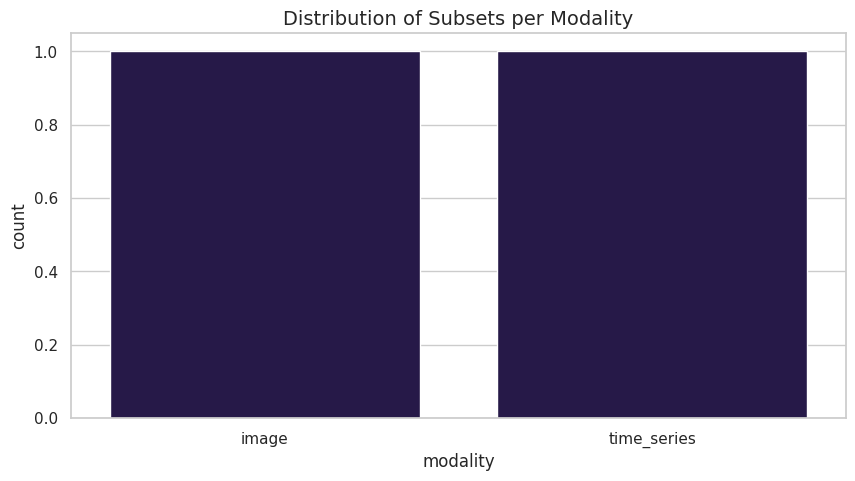

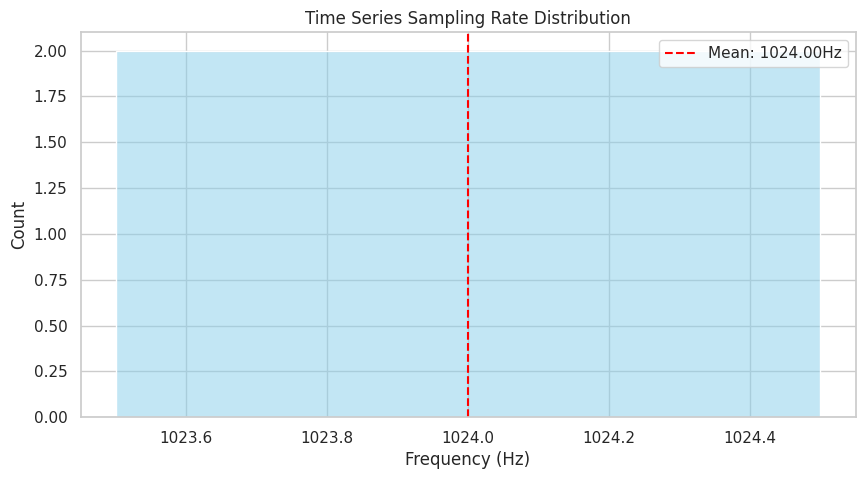

In [35]:
# Use the visualizer to check if your data is balanced
viz.plot_modality_balance()

# Fetch metadata for deep-dive plots
ts_metadata = factory.fetch_modality_subset("time_series")
viz.plot_temporal_distribution(ts_metadata)

In [41]:
sample_images = factory.fetch_modality_subset("image")
sample_images
# viz.plot_sample_images(sample_images, n=4)

[{'name': 'hubble_deep',
  'registered_at': Timestamp('2026-03-11 22:30:22.324736'),
  'resolution': '4k'},
 {'name': 'hubble_deep',
  'registered_at': Timestamp('2026-03-11 22:40:56.129036'),
  'resolution': '4k'}]

Opening stream to MultimodalUniverse/legacysurvey...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Successfully fetched 4 examples via stream.


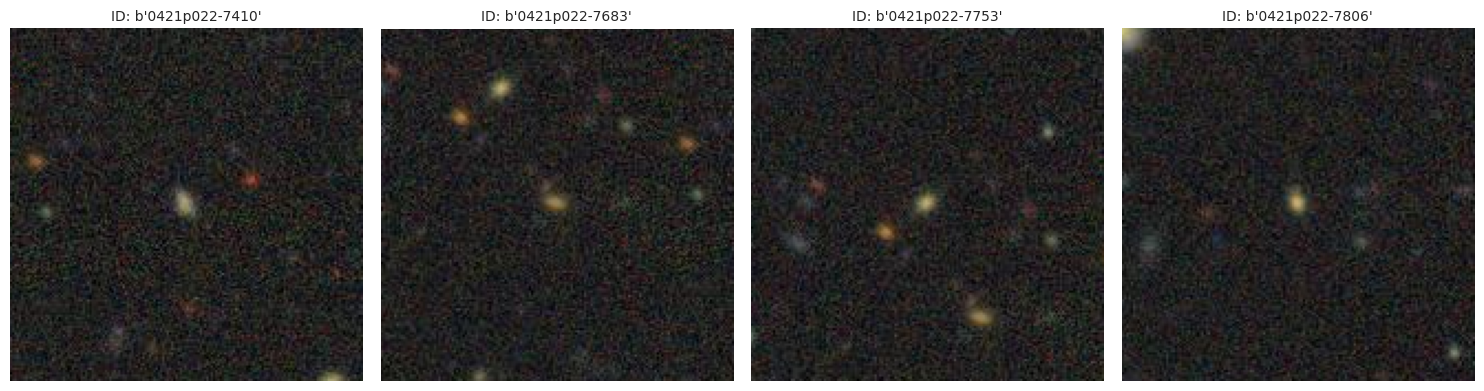

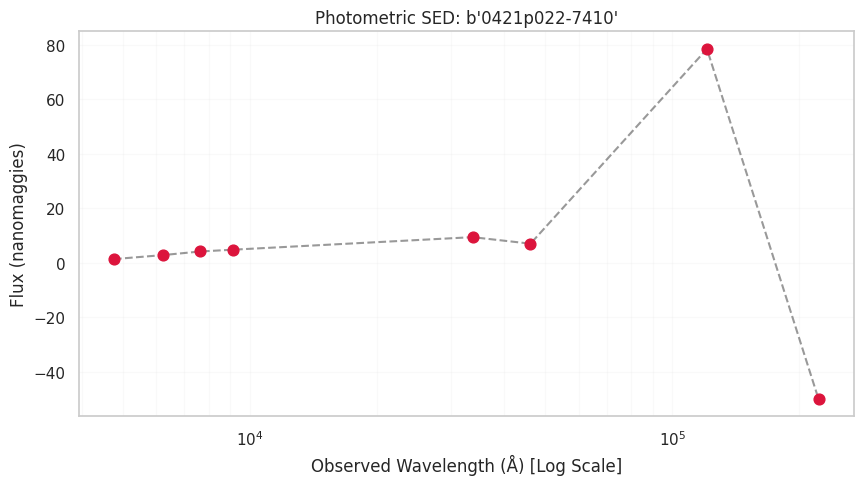

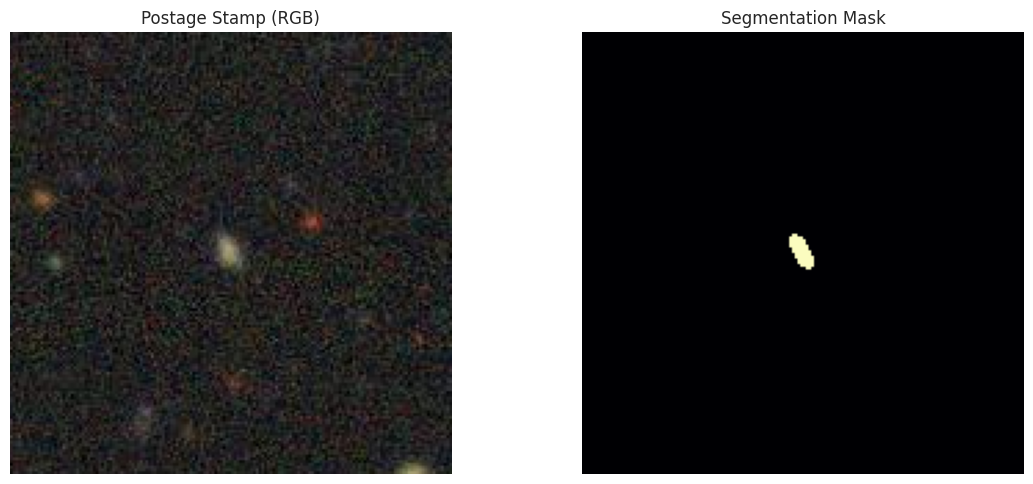

In [56]:
# 1. Initialize
factory = MultimodalDatasetFactory(base_path="hf_hub") # base_path is symbolic here
viz = UniverseVisualizer(pd.DataFrame()) # Empty manifest is fine for sample plotting

# 2. Use the Factory to get examples from the cloud
# This is where your 6.5 Mbps connection fetches just the necessary bytes
examples = factory.get_streaming_examples(
    path="MultimodalUniverse/legacysurvey",
    n_samples=4
)

# 3. Hand off to Visualizer (Visualisation_mod.py)
# Plot the 4 postage stamps
viz.plot_sample_images(examples, n=4)

# Plot the SED of the first galaxy in the stream
viz.plot_photometric_sed(examples[0])

# Check the mask for the same galaxy
viz.plot_spatial_grasp(examples[0])